# Resultados para el congreso IDEAL 2026

In [6]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from IPython.display import display
from scipy.stats import pearsonr, spearmanr

In [2]:
import os
os.chdir("..")
root_path = os.getcwd()
# from Comparison_RealDatasets import *
# from DistributedFS_Complexity_RealDatasets import *

In [3]:
root_path

'/home/carmen/PycharmProjects/FeatureSelection_Complexity'

Leemos la tabla comparativa para todos los datasets artificiales.

In [20]:
# Leer todos los comparison.csv de la carpeta
files = glob.glob("Results_FS_ComplexityEvaluation/*_comparisonTable.csv")

all_tables = []
for f in files:
    df = pd.read_csv(f, index_col=[0,1])
    all_tables.append(df)

comparison_all = pd.concat(all_tables)
comparison_all = comparison_all.reset_index()  # convierte Dataset/Subset en columnas
comparison_all.head()


,Dataset,Subset,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,...,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
0,ArtificialDataset9,all,0.122333,0.124800,0.115908,0.467111,0.353002,0.100735,0.456456,0.987934,...,0.072675,0.890150,0.964661,0.074656,0.874500,0.960000,0.112236,0.907583,0.969333,0.050094
1,ArtificialDataset9,informative,0.043333,0.068600,0.070806,0.536417,0.247868,0.057011,0.383627,0.970831,...,0.062205,0.910028,0.977665,0.062268,0.914250,0.974000,0.057230,0.905917,0.981333,0.069048
2,ArtificialDataset9,informative+redundant,0.051333,0.083600,0.049074,0.596311,0.316356,0.062120,0.396705,0.979240,...,0.069456,0.902372,0.974331,0.069519,0.905750,0.969333,0.064460,0.899083,0.981333,0.075106
3,ArtificialDataset9,informative+redundant_nonLinear,0.072000,0.089333,0.056298,0.611812,0.386746,0.065112,0.402679,0.983451,...,0.100109,0.883379,0.968998,0.113493,0.854333,0.965333,0.189368,0.923000,0.972667,0.050583
4,ArtificialDataset9,informative+noise,0.182667,0.236667,0.063926,0.535157,0.247209,0.201594,0.481259,0.996496,...,0.051396,0.884214,0.956990,0.051456,0.890333,0.951333,0.041948,0.878250,0.962667,0.063311


In [5]:
comparison_all.loc['ArtificialDataset1']

,Hostility,kDN,DCP,TD_U,CLD,N1,N2,LSC,F1,L1,...,mean_acc_std,mean_gps_mean,mean_gps_max,mean_gps_std,mean_acc_class_0_mean,mean_acc_class_0_max,mean_acc_class_0_std,mean_acc_class_1_mean,mean_acc_class_1_max,mean_acc_class_1_std
Subset,,,,,,,,,,,,,,,,,,,,,
all,0.046,0.0690,0.044942,0.612727,0.147362,0.051942,0.401273,0.958403,0.976333,0.739084,...,0.032801,0.954202,0.985998,0.032864,0.95675,0.982,0.028484,0.95175,0.990,0.038299
informative,0.035,0.0510,0.016597,0.599091,0.146010,0.033283,0.373701,0.944228,0.974700,0.695393,...,0.032849,0.957720,0.989999,0.032885,0.95300,0.988,0.036551,0.96250,0.996,0.029737
informative+redundant,0.037,0.0528,0.010725,0.613545,0.160466,0.033117,0.372744,0.944631,0.971643,0.797456,...,0.035569,0.953950,0.987999,0.035633,0.95125,0.986,0.038366,0.95675,0.992,0.033551
informative+redundant_nonLinear,0.034,0.0608,0.016597,0.599364,0.141838,0.039467,0.379799,0.955178,0.977250,0.661763,...,0.035808,0.954700,0.988998,0.035874,0.95250,0.982,0.035613,0.95700,0.996,0.036520
informative+noise,0.042,0.0664,0.098407,0.550667,0.141574,0.043424,0.407718,0.962517,0.978167,0.664564,...,0.034924,0.953584,0.984997,0.034964,0.95125,0.984,0.035568,0.95600,0.986,0.035067
informative+rand_extra,0.041,0.0606,0.009774,0.607455,0.164299,0.047826,0.390360,0.950563,0.972231,0.722216,...,0.031861,0.955459,0.986998,0.031906,0.95275,0.982,0.032880,0.95825,0.992,0.031739
mutual_info_top10,0.064,0.0892,0.117013,0.546615,0.169743,0.087900,0.362421,0.953158,0.963900,0.061728,...,0.028762,0.928774,0.954952,0.028829,0.93600,0.974,0.040341,0.92175,0.942,0.019047
f_classif_top10,0.072,0.1036,0.063668,0.552083,0.168073,0.098893,0.382324,0.950649,0.966300,0.759174,...,0.025467,0.927540,0.959983,0.025527,0.93375,0.972,0.029615,0.92150,0.948,0.022822
rf_top10,0.048,0.0674,0.046560,0.764444,0.156921,0.060602,0.353386,0.921090,0.964200,0.090498,...,0.029256,0.935680,0.972986,0.029302,0.93975,0.984,0.033982,0.93175,0.962,0.024967


In [63]:
# === CONFIG ===
COMPLEXITY_COLS = ["Hostility","kDN","DCP","TD_U","CLD","N1","N2","LSC","F1","L1"]
PERF_COLS = ["mean_acc_mean", "mean_gps_mean"]

# === LOAD ===
df = comparison_all


In [64]:
def rank_series(s, ascending=True):
    # method='average' maneja empates de forma estándar
    return s.rank(ascending=ascending, method="average")

rows_pearson = []
rows_spearman = []

for dataset, g in df.groupby("Dataset", dropna=False):
    g = g.copy()

    # Rankings: complejidad ascendente, performance descendente
    for c in COMPLEXITY_COLS:
        g[f"rank_{c}"] = rank_series(g[c], ascending=True)
    for p in PERF_COLS:
        g[f"rank_{p}"] = rank_series(g[p], ascending=False)

    # --- Pearson (valores) ---
    for c in COMPLEXITY_COLS:
        for p in PERF_COLS:
            sub = g[[c, p]].dropna()
            if len(sub) >= 3 and sub[c].nunique() > 1 and sub[p].nunique() > 1:
                r, pv = pearsonr(sub[c], sub[p])
            else:
                r, pv = (np.nan, np.nan)
            rows_pearson.append({
                "Dataset": dataset, "Complexity": c, "Performance": p,
                "pearson_r": r, "pearson_p": pv, "n": len(sub)
            })

    # --- Spearman (valores y rankings) ---
    for c in COMPLEXITY_COLS:
        for p in PERF_COLS:
            sub_val = g[[c, p]].dropna()
            if len(sub_val) >= 3 and sub_val[c].nunique() > 1 and sub_val[p].nunique() > 1:
                rho_val, pv_val = spearmanr(sub_val[c], sub_val[p])
            else:
                rho_val, pv_val = (np.nan, np.nan)

            rc, rp = f"rank_{c}", f"rank_{p}"
            sub_rank = g[[rc, rp]].dropna()
            if len(sub_rank) >= 3 and sub_rank[rc].nunique() > 1 and sub_rank[rp].nunique() > 1:
                rho_rank, pv_rank = spearmanr(sub_rank[rc], sub_rank[rp])
            else:
                rho_rank, pv_rank = (np.nan, np.nan)

            rows_spearman.append({
                "Dataset": dataset, "Complexity": c, "Performance": p,
                "spearman_rho_values": rho_val, "spearman_p_values": pv_val,
                "spearman_rho_ranks": rho_rank, "spearman_p_ranks": pv_rank,
                "n": len(sub_val)
            })

    # Si quieres guardar la tabla con rankings por dataset:
    # g.to_csv(f"{dataset}_with_ranks.csv", index=False)

pearson_df = pd.DataFrame(rows_pearson)
spearman_df = pd.DataFrame(rows_spearman)

# --- RESULTADOS por dataset: ordena por rho_ranks (más negativo = mejor “ordena como esperas”) ---
spearman_df_sorted = spearman_df.sort_values(
    by=["Dataset","Performance","spearman_rho_ranks"],
    ascending=[True, True, True]
)

print("=== Pearson (primeras filas) ===")
print(pearson_df.head(10))

print("\n=== Spearman (ordenado por rho_ranks) ===")
print(spearman_df_sorted.head(20))


=== Pearson (primeras filas) ===
              Dataset Complexity    Performance  pearson_r  pearson_p   n
0  ArtificialDataset1  Hostility  mean_acc_mean  -0.886497   0.000277  11
1  ArtificialDataset1  Hostility  mean_gps_mean  -0.886502   0.000277  11
2  ArtificialDataset1        kDN  mean_acc_mean  -0.826883   0.001693  11
3  ArtificialDataset1        kDN  mean_gps_mean  -0.826895   0.001693  11
4  ArtificialDataset1        DCP  mean_acc_mean  -0.508949   0.109853  11
5  ArtificialDataset1        DCP  mean_gps_mean  -0.509104   0.109726  11
6  ArtificialDataset1       TD_U  mean_acc_mean  -0.236603   0.483635  11
7  ArtificialDataset1       TD_U  mean_gps_mean  -0.236407   0.484008  11
8  ArtificialDataset1        CLD  mean_acc_mean  -0.686414   0.019668  11
9  ArtificialDataset1        CLD  mean_gps_mean  -0.686476   0.019652  11

=== Spearman (ordenado por rho_ranks) ===
               Dataset Complexity    Performance  spearman_rho_values  \
16  ArtificialDataset1         F1  me

In [13]:
pearson_df

,Dataset,Complexity,Performance,pearson_r,pearson_p,n
0,ArtificialDataset1,Hostility,mean_acc_mean,-0.886497,0.000277,11
1,ArtificialDataset1,Hostility,mean_gps_mean,-0.886502,0.000277,11
2,ArtificialDataset1,kDN,mean_acc_mean,-0.826883,0.001693,11
3,ArtificialDataset1,kDN,mean_gps_mean,-0.826895,0.001693,11
4,ArtificialDataset1,DCP,mean_acc_mean,-0.508949,0.109853,11
...,...,...,...,...,...,...
455,ArtificialDataset9,LSC,mean_gps_mean,-0.175884,0.604945,11
456,ArtificialDataset9,F1,mean_acc_mean,0.635600,0.035577,11
457,ArtificialDataset9,F1,mean_gps_mean,0.622213,0.040930,11
458,ArtificialDataset9,L1,mean_acc_mean,-0.028593,0.933494,11


In [45]:

# === SUMMARY GLOBAL ===
# Ejemplo: media y mediana de rho_ranks por medida de complejidad y performance
summary = (spearman_df
           .groupby(["Complexity","Performance"], as_index=False)
           .agg(rho_ranks_mean=("spearman_rho_ranks","mean"),
                rho_ranks_median=("spearman_rho_ranks","median"),
                rho_values_mean=("spearman_rho_values","mean"),
                count=("spearman_rho_ranks","count")))
summary = summary.sort_values(["Performance","rho_ranks_mean"], ascending=[True, True])

print("\n=== Summary global ===")
print(summary)


=== Summary global ===
   Complexity    Performance  rho_ranks_mean  rho_ranks_median  \
4          F1  mean_acc_mean       -0.347576         -0.419135   
16       TD_U  mean_acc_mean       -0.119267         -0.045558   
8          L1  mean_acc_mean        0.109357          0.018182   
14         N2  mean_acc_mean        0.210530          0.272727   
2         DCP  mean_acc_mean        0.231610          0.500000   
10        LSC  mean_acc_mean        0.396421          0.490909   
0         CLD  mean_acc_mean        0.543752          0.596812   
6   Hostility  mean_acc_mean        0.594796          0.669753   
12         N1  mean_acc_mean        0.624219          0.681818   
18        kDN  mean_acc_mean        0.659082          0.690909   
5          F1  mean_gps_mean       -0.380700         -0.490909   
17       TD_U  mean_gps_mean       -0.084083         -0.004556   
9          L1  mean_gps_mean        0.114411          0.090909   
15         N2  mean_gps_mean        0.181911        

In [46]:
df

,index,Dataset,Subset,Hostility,kDN,DCP,TD_U,CLD,N1,N2,...,rank_DCP,rank_TD_U,rank_CLD,rank_N1,rank_N2,rank_LSC,rank_F1,rank_L1,rank_mean_acc_mean,rank_mean_gps_mean
0,0,ArtificialDataset9,all,0.122333,0.124800,0.115908,0.467111,0.353002,0.100735,0.456456,...,9.0,4.0,10.0,6.0,10.0,10.0,10.0,10.0,4.0,4.0
1,1,ArtificialDataset9,informative,0.043333,0.068600,0.070806,0.536417,0.247868,0.057011,0.383627,...,4.0,7.0,3.0,1.0,2.0,2.0,7.0,5.0,1.0,1.0
2,2,ArtificialDataset9,informative+redundant,0.051333,0.083600,0.049074,0.596311,0.316356,0.062120,0.396705,...,1.0,10.0,8.0,2.0,6.0,4.0,6.0,9.0,2.0,2.0
3,3,ArtificialDataset9,informative+redundant_nonLinear,0.072000,0.089333,0.056298,0.611812,0.386746,0.065112,0.402679,...,2.0,11.0,11.0,4.0,8.0,9.0,9.0,3.0,5.0,6.0
4,4,ArtificialDataset9,informative+noise,0.182667,0.236667,0.063926,0.535157,0.247209,0.201594,0.481259,...,3.0,6.0,2.0,11.0,11.0,11.0,11.0,2.0,6.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
248,248,ArtificialDataset7,mutual_info_top20,0.022000,0.043200,0.043262,0.753600,0.144102,0.038703,0.393945,...,5.5,10.0,9.0,8.0,3.0,2.0,1.0,2.0,10.5,10.0
249,249,ArtificialDataset7,f_classif_top20,0.024000,0.046400,0.003902,0.725600,0.093106,0.039335,0.396194,...,1.0,5.0,5.0,9.0,4.0,5.0,3.0,1.0,7.0,7.0
250,250,ArtificialDataset7,rf_top20,0.023000,0.035000,0.047594,0.746100,0.129881,0.033210,0.391093,...,7.0,8.0,7.0,6.0,1.0,3.0,2.0,8.0,9.0,9.0
251,251,ArtificialDataset7,relief_top20,0.019000,0.037000,0.043262,0.725700,0.086856,0.027986,0.392033,...,5.5,6.0,4.0,5.0,2.0,1.0,4.0,3.0,4.0,4.0


In [47]:
df[df["Dataset"] == 'ArtificialDataset1']

,index,Dataset,Subset,Hostility,kDN,DCP,TD_U,CLD,N1,N2,...,rank_DCP,rank_TD_U,rank_CLD,rank_N1,rank_N2,rank_LSC,rank_F1,rank_L1,rank_mean_acc_mean,rank_mean_gps_mean
121,121,ArtificialDataset1,all,0.046,0.0690,0.044942,0.612727,0.147362,0.051942,0.401273,...,6.0,7.0,4.0,6.0,10.0,10.0,9.0,8.0,4.0,4.0
122,122,ArtificialDataset1,informative,0.035,0.0510,0.016597,0.599091,0.146010,0.033283,0.373701,...,5.0,4.0,3.0,2.0,6.0,3.0,8.0,6.0,1.0,1.0
123,123,ArtificialDataset1,informative+redundant,0.037,0.0528,0.010725,0.613545,0.160466,0.033117,0.372744,...,2.0,8.0,7.0,1.0,5.0,4.0,6.0,10.0,5.0,5.0
124,124,ArtificialDataset1,informative+redundant_nonLinear,0.034,0.0608,0.016597,0.599364,0.141838,0.039467,0.379799,...,4.0,5.0,2.0,3.0,7.0,9.0,10.0,4.0,3.0,3.0
125,125,ArtificialDataset1,informative+noise,0.042,0.0664,0.098407,0.550667,0.141574,0.043424,0.407718,...,10.0,2.0,1.0,4.0,11.0,11.0,11.0,5.0,6.0,6.0
126,126,ArtificialDataset1,informative+rand_extra,0.041,0.0606,0.009774,0.607455,0.164299,0.047826,0.390360,...,1.0,6.0,8.0,5.0,9.0,5.0,7.0,7.0,2.0,2.0
127,127,ArtificialDataset1,mutual_info_top10,0.064,0.0892,0.117013,0.546615,0.169743,0.087900,0.362421,...,11.0,1.0,11.0,10.0,3.0,8.0,1.0,1.0,10.0,10.0
128,128,ArtificialDataset1,f_classif_top10,0.072,0.1036,0.063668,0.552083,0.168073,0.098893,0.382324,...,9.0,3.0,10.0,11.0,8.0,6.0,5.0,9.0,11.0,11.0
129,129,ArtificialDataset1,rf_top10,0.048,0.0674,0.046560,0.764444,0.156921,0.060602,0.353386,...,7.5,10.5,5.5,7.5,1.5,1.5,2.5,3.0,8.0,8.0
130,130,ArtificialDataset1,relief_top10,0.048,0.0674,0.046560,0.764444,0.156921,0.060602,0.353386,...,7.5,10.5,5.5,7.5,1.5,1.5,2.5,2.0,9.0,9.0


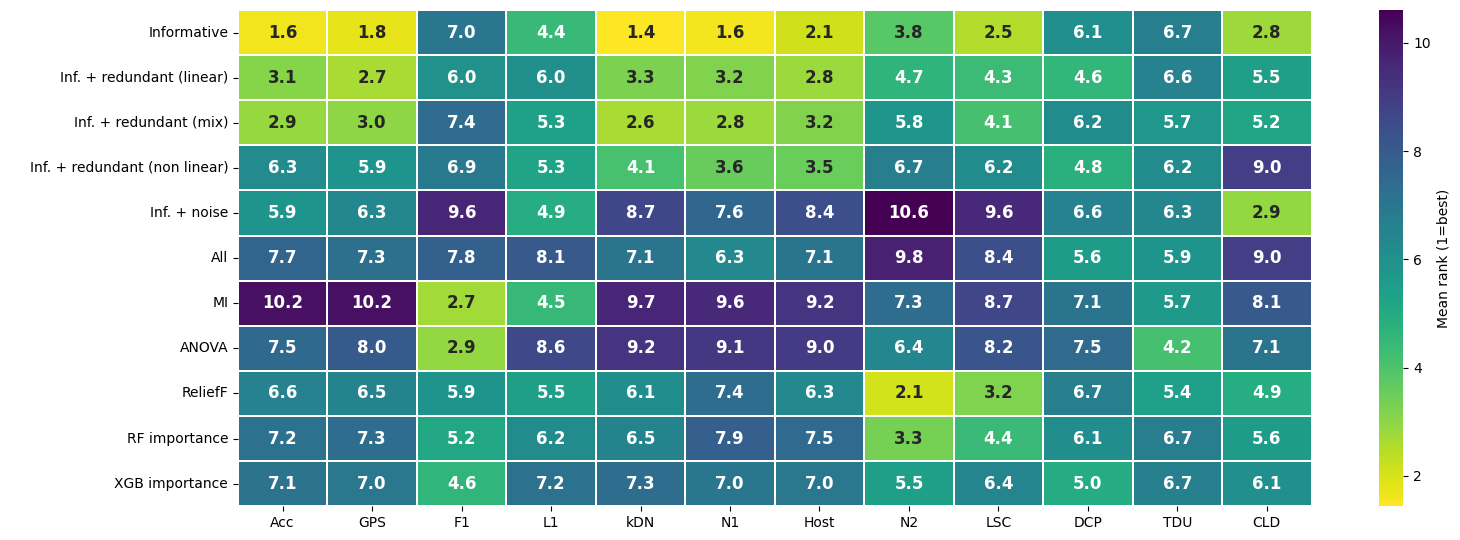

In [42]:
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------- 1) Prepara el DF ----------
# comparison_all viene de tu concat con index_col=[0,1]
df = comparison_all.reset_index()  # columnas: Dataset, Subset, ...

# ---------- 2) Define columnas ----------
COMPLEXITY_COLS = ["Hostility","kDN","DCP","TD_U","CLD","N1","N2","LSC","F1","L1"]
PERF_COLS = ["mean_acc_mean", "mean_gps_mean"]  # ajusta si en tus CSV se llaman distinto

# Asegurar que existen (por si algún CSV no tiene todas)
COMPLEXITY_COLS = [c for c in COMPLEXITY_COLS if c in df.columns]
PERF_COLS = [c for c in PERF_COLS if c in df.columns]
ALL_METRICS = COMPLEXITY_COLS + PERF_COLS

# Convertir a numérico
for c in ALL_METRICS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# ---------- 3) Limpia nombres de subsets SOTA ----------
# Quita sufijo "_topXX" o "_topXXXX" etc.
# Ej: "mutual_info_top10" -> "mutual_info"
#     "xgb_top70" -> "xgb"
df["Subset_clean"] = df["Subset"].astype(str).str.replace(r"_top\d+$", "", regex=True)

# (Opcional) nombres más “bonitos” para el congreso:
pretty_map = {
    "mutual_info": "MI",
    "f_classif": "ANOVA",
    "relief": "ReliefF",
    "rf": "RF importance",
    "xgb": "XGB importance",
    "informative": "Informative",
    "all": "All",
    "informative+redundant": "Inf. + redundant (linear)",
    "informative+redundant_nonLinear": "Inf. + redundant (non linear)",
    "informative+noise": "Inf. + noise",
    "informative+rand_extra": "Inf. + redundant (mix)"
}

df["Subset_clean"] = df["Subset_clean"].replace(pretty_map)

# ---------- 4) Ranking dentro de cada dataset ----------
# Complejidad: asc (1=menor complejidad)
# Performance: desc (1=mejor rendimiento)
rank_cols = []
for ds, g in df.groupby("Dataset", dropna=False):
    idx = g.index

    for c in COMPLEXITY_COLS:
        df.loc[idx, f"rank_{c}"] = g[c].rank(ascending=True, method="average")
        rank_cols.append(f"rank_{c}")

    for p in PERF_COLS:
        df.loc[idx, f"rank_{p}"] = g[p].rank(ascending=False, method="average")
        rank_cols.append(f"rank_{p}")

rank_cols = sorted(set(rank_cols))

# ---------- 5) Media del ranking por subset (promediado sobre datasets) ----------
rank_mean = (
    df.groupby("Subset_clean")[rank_cols]
      .mean()
      .rename(index=str)
)

# Renombrar columnas para que no salga "rank_"
rank_mean.columns = [c.replace("rank_", "") for c in rank_mean.columns]

col_order = ["mean_acc_mean","mean_gps_mean","F1","L1", "kDN","N1","Hostility","N2","LSC","DCP","TD_U","CLD"]


rank_mean = rank_mean.reindex(columns=[c for c in col_order if c in rank_mean.columns])

col_rename = {
    "mean_acc_mean": "Acc",
    "mean_gps_mean": "GPS",
    "Hostility": "Host",
    "TD_U": "TDU"
}
rank_mean = rank_mean.rename(columns=col_rename)


row_order = [
    "Informative",
    "Inf. + redundant (linear)",
    "Inf. + redundant (mix)",
    "Inf. + redundant (non linear)",
    "Inf. + noise",
    "All",
    "MI",
    "ANOVA",
    "ReliefF",
    "RF importance",
    "XGB importance"
]
rank_mean = rank_mean.reindex(index=[r for r in row_order if r in rank_mean.index])

# ---------- 6) Orden de filas (subsets) para que sea legible ----------
# Ponemos primero los "conceptuales" y luego SOTA
#preferred = ["informative", "all", "informative+redundant", "informative+redundant_nonLinear", "informative+noise"]
#preferred = [s for s in preferred if s in rank_mean.index]

# el resto en orden alfabético
#others = [s for s in rank_mean.index if s not in preferred]
#rank_mean = rank_mean.loc[preferred + sorted(others)]

# ---------- 7) Plot heatmap ----------
plt.figure(figsize=(16, max(4, 0.5*rank_mean.shape[0])))  # altura adaptativa
ax = sns.heatmap(
    rank_mean,
    cmap="viridis_r",   # 1=best en amarillo claro si usas _r (depende del mapa)
    annot=True, fmt=".1f",
    annot_kws={"size": 12, "weight": "bold"},
    linewidths=.3, linecolor="white",
    cbar_kws={"label": "Mean rank (1=best)"}
)

#ax.set_title("Mean ranking across datasets (complexity asc; performance desc)")
#ax.set_xlabel("Metrics")
ax.set_ylabel(" ")


plt.tight_layout()
plt.show()

In [65]:
spearman_df

,Dataset,Complexity,Performance,spearman_rho_values,spearman_p_values,spearman_rho_ranks,spearman_p_ranks,n
0,ArtificialDataset1,Hostility,mean_acc_mean,-0.888385,0.000258,0.888385,0.000258,11
1,ArtificialDataset1,Hostility,mean_gps_mean,-0.888385,0.000258,0.888385,0.000258,11
2,ArtificialDataset1,kDN,mean_acc_mean,-0.815492,0.002216,0.815492,0.002216,11
3,ArtificialDataset1,kDN,mean_gps_mean,-0.815492,0.002216,0.815492,0.002216,11
4,ArtificialDataset1,DCP,mean_acc_mean,-0.678817,0.021637,0.678817,0.021637,11
...,...,...,...,...,...,...,...,...
455,ArtificialDataset9,LSC,mean_gps_mean,-0.272727,0.417141,0.272727,0.417141,11
456,ArtificialDataset9,F1,mean_acc_mean,0.636364,0.035287,-0.636364,0.035287,11
457,ArtificialDataset9,F1,mean_gps_mean,0.654545,0.028865,-0.654545,0.028865,11
458,ArtificialDataset9,L1,mean_acc_mean,0.036364,0.915468,-0.036364,0.915468,11


/tmp/ipykernel_7231/3890927894.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([name_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])


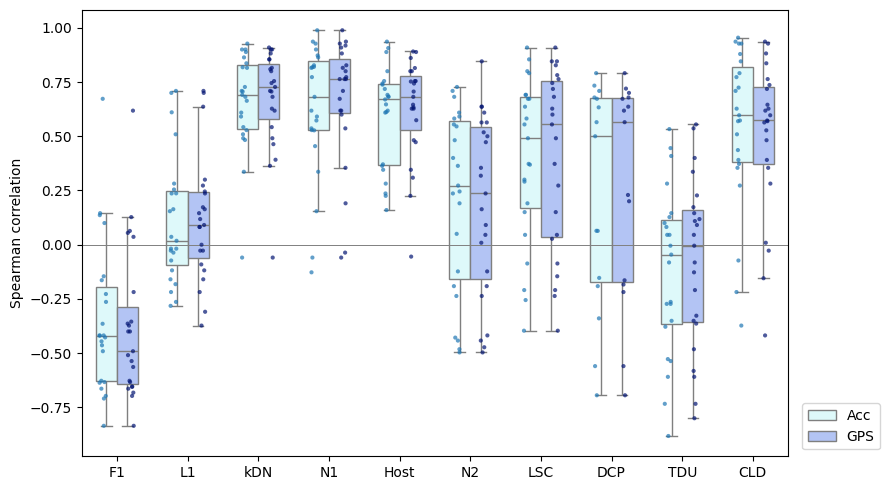

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

d = spearman_df.copy()
d["Performance"] = d["Performance"].replace({
    "mean_acc_mean": "Acc",
    "mean_gps_mean": "GPS"
})


# 1) Orden y nombres bonitos (ver secciones 2 y 3)
order = ["F1","L1","kDN","N1","Hostility","N2","LSC","DCP","TD_U","CLD"]  # pon el orden que quieras
name_map = {
    "Hostility": "Host",
    "TD_U": "TDU",
    "CLD": "CLD",
    "DCP": "DCP",
    "kDN": "kDN",
    "N1": "N1",
    "N2": "N2",
    "LSC": "LSC",
    "F1": "F1",
    "L1": "L1",
}


# 2) Paleta suave boxplot
palette = {"Acc": "#D9FDFF", "GPS": "#A8BFFF"}  # azul/azul oscuro suaves

# Paleta para los puntos
palette_pts = {"Acc": "#1f77b4", "GPS": "#031573"}


plt.figure(figsize=(9, 5))
ax = sns.boxplot(data=d, x="Complexity", y="spearman_rho_ranks", hue="Performance",
                 order=order,palette=palette,
                 width=0.6, fliersize=0)
sns.stripplot(data=d, x="Complexity", y="spearman_rho_ranks", hue="Performance",
              order=order,
              dodge=True,palette=palette_pts,
              alpha=0.7, size=3, linewidth=0)

# quita leyenda duplicada
h, l = ax.get_legend_handles_labels()
ax.legend(h[:2], l[:2], title="", loc="lower left", bbox_to_anchor=(1.01, 0))

ax.axhline(0, color="gray", lw=0.7)

# Renombrar ticks del eje X
ax.set_xticklabels([name_map.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()])

ax.set_ylabel("Spearman correlation")
ax.set_xlabel("")
# ax.set_title("Agreement between complexity-ranks and performance-ranks (per dataset)")
plt.tight_layout()
plt.show()

In [57]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

COMPLEXITY_COLS = ["Hostility","kDN","N1"]  # añade si quieres
PERF_COLS = ["mean_acc_mean","mean_gps_mean"]

df = comparison_all.reset_index()  # Dataset, Subset, ...

# Asegura numéricos
for c in COMPLEXITY_COLS + PERF_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

def add_ranks(df):
    out = []
    for ds, g in df.groupby("Dataset", dropna=False):
        g = g.copy()
        # complejidad: ascendente (1=menor)
        for c in COMPLEXITY_COLS:
            g[f"r_{c}"] = g[c].rank(ascending=True, method="average")
        # performance: descendente (1=mejor)
        for p in PERF_COLS:
            g[f"r_{p}"] = g[p].rank(ascending=False, method="average")
        out.append(g)
    return pd.concat(out, ignore_index=True)

df_r = add_ranks(df)

# Spearman por dataset (entre rankings)
rows = []
for ds, g in df_r.groupby("Dataset"):
    for c in COMPLEXITY_COLS:
        for p in PERF_COLS:
            x, y = g[f"r_{c}"], g[f"r_{p}"]
            if x.nunique() > 1 and y.nunique() > 1 and len(g) >= 3:
                rho, pv = spearmanr(x, y, nan_policy="omit")
            else:
                rho, pv = np.nan, np.nan
            rows.append({"Dataset": ds, "Complexity": c, "Performance": p, "rho": rho, "p": pv})

spearman_df = pd.DataFrame(rows)

# Resumen robusto (mediana + IQR) y % de datasets con rho negativo
summary = (spearman_df
           .groupby(["Complexity","Performance"], as_index=False)
           .agg(
               rho_median=("rho","median"),
               rho_q25=("rho", lambda s: np.nanquantile(s, 0.25)),
               rho_q75=("rho", lambda s: np.nanquantile(s, 0.75)),
               frac_negative=("rho", lambda s: np.nanmean(s < 0)),
               n=("rho","count")
           ))
summary["IQR"] = summary["rho_q75"] - summary["rho_q25"]
summary


,Complexity,Performance,rho_median,rho_q25,rho_q75,frac_negative,n,IQR
0,Hostility,mean_acc_mean,0.669753,0.367177,0.740597,0.000000,23,0.373419
1,Hostility,mean_gps_mean,0.681818,0.527926,0.777273,0.043478,23,0.249347
2,N1,mean_acc_mean,0.681818,0.527874,0.845455,0.086957,23,0.317581
3,N1,mean_gps_mean,0.763636,0.609091,0.854545,0.086957,23,0.245455
4,kDN,mean_acc_mean,0.690909,0.535309,0.827273,0.043478,23,0.291964
5,kDN,mean_gps_mean,0.727273,0.580162,0.835019,0.043478,23,0.254856
